# Animal Tagging & Oceanographic Context near Tasmania

> *Explore animal satellite relay tagging data near Tasmania, showing foraging tracks and CTD profiles from tagged seals and turtles, plus contextual datasets (Argo floats, Maria Island NRS mooring, gridded SST and Chl-a) to understand the oceanographic environment.*

In [1]:
import os, requests, importlib.util, warnings
warnings.filterwarnings('ignore')

open('setup.py', 'w').write(
    requests.get(
        'https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py'
    ).text
)
spec = importlib.util.spec_from_file_location('setup', 'setup.py')
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
setup.install_requirements()
setup.load_dataquery()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from DataQuery import GetAodn, plot_ts_diagram

aodn = GetAodn()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 124ms
Checked 201 packages in 1ms


✅ Local version 0.3.25 is up to date (remote: 0.3.18)


## Study Region — Tasmania

All queries are restricted to the waters around Tasmania and the nearby Southern Ocean/East Australian shelf.

| Parameter | Value |
|-----------|-------|
| **Latitude** | −50 °S → −40 °S |
| **Longitude** | 143 °E → 154 °E |
| **Period** | 2010-01-01 → 2023-12-31 |

In [2]:

# ── Study region ───────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -50, -40
LON_MIN, LON_MAX = 143, 154
DATE_START, DATE_END = "2010-01-01", "2023-12-31"

# Maria Island NRS mooring (approximate position)
MARIA_LAT, MARIA_LON = -42.60, 148.23
print(f"Region: {LAT_MIN}°–{LAT_MAX}° S, {LON_MIN}°–{LON_MAX}° E  |  {DATE_START} → {DATE_END}")

Region: -50°–-40° S, 143°–154° E  |  2010-01-01 → 2023-12-31


---
## 1. Animal Satellite Relay Tagging — CTD profiles (seals & turtles)

CTD-SRDLs (Conductivity-Temperature-Depth Satellite Relay Data Loggers) are deployed on elephant seals, fur seals, Weddell seals, and (from 2024) flatback and olive ridley turtles. The instruments transmit temperature, salinity and pressure profiles via the Argos satellite system.

Here we:
1. Load all quality-controlled profiles within the Tasmania box.
2. Map the animal foraging tracks (scatter of fix positions).
3. Plot mean temperature and salinity profiles per platform type.
4. Draw a T-S diagram coloured by pressure.

In [3]:

ds_animal = aodn.get_dataset("animal_ctd_satellite_relay_tagging_delayed_qc.parquet")
print(ds_animal.get_temporal_extent())

(Timestamp('2004-01-27 11:49:00'), Timestamp('2024-02-22 12:45:00'))


In [4]:

df_animal = ds_animal.get_data(
    date_start=DATE_START,
    date_end=DATE_END,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)
print(f"Animal CTD rows: {len(df_animal):,}  |  platforms: {df_animal['PLATFORM_NUMBER'].nunique()}")
df_animal.head(3)

2026-06-03 15:10:35,405 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_ctd_satellite_relay_tagging_delayed_qc.parquet


Animal CTD rows: 29,536  |  platforms: 3


,PROJECT_NAME,PI_NAME,CYCLE_NUMBER,DIRECTION,DATA_CENTRE,DC_REFERENCE,DATA_STATE_INDICATOR,DATA_MODE,INST_REFERENCE,WMO_INST_TYPE,...,LIGHT_QC,LIGHT_ADJUSTED,LIGHT_ADJUSTED_ERROR,LIGHT_ADJUSTED_QC,PARAMETER,SCIENTIFIC_CALIB_EQUATION,SCIENTIFIC_CALIB_COEFFICIENT,timestamp,PLATFORM_NUMBER,polygon
0,...,...,36.0,A,IF,,,D,...,995,...,None,NaN,NaN,None,None,None,None,1325376000,30414,0103000000010000000500000000000000002062400000...
1,...,...,36.0,A,IF,,,D,...,995,...,None,NaN,NaN,None,None,None,None,1325376000,30414,0103000000010000000500000000000000002062400000...
2,...,...,36.0,A,IF,,,D,...,995,...,None,NaN,NaN,None,None,None,None,1325376000,30414,0103000000010000000500000000000000002062400000...


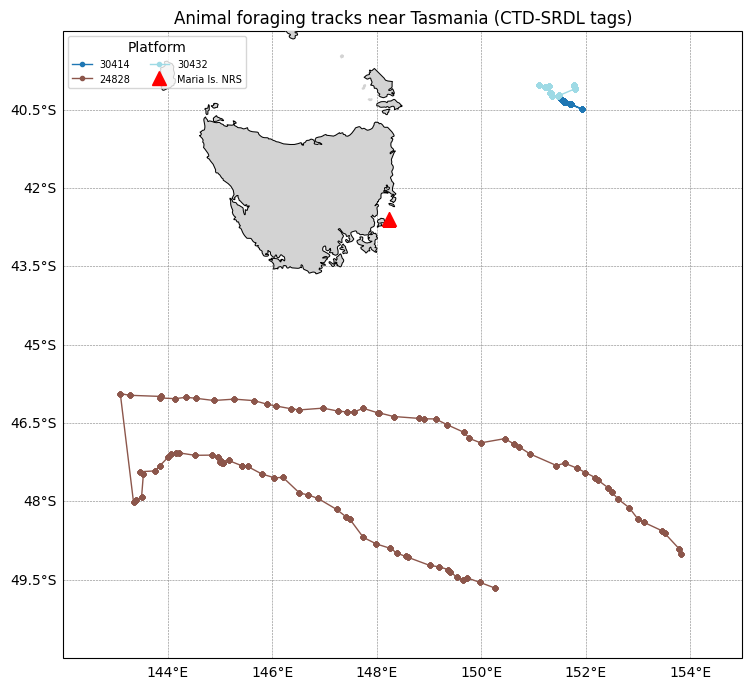

In [5]:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

if df_animal.empty:
    print("No animal tracking data in this region/period.")
else:
    platforms = df_animal["PLATFORM_NUMBER"].unique()
    cmap = plt.get_cmap("tab20", len(platforms))

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN - 1, LON_MAX + 1, LAT_MIN - 1, LAT_MAX + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    for i, pid in enumerate(platforms):
        sub = df_animal[df_animal["PLATFORM_NUMBER"] == pid].dropna(subset=["LATITUDE", "LONGITUDE"])
        sub_sorted = sub.sort_values("JULD")
        ax.plot(sub_sorted["LONGITUDE"], sub_sorted["LATITUDE"],
                "-o", markersize=3, linewidth=1, color=cmap(i), label=str(pid), transform=ccrs.PlateCarree())

    # Mark Maria Island NRS
    ax.plot(MARIA_LON, MARIA_LAT, "r^", markersize=10, transform=ccrs.PlateCarree(), zorder=5, label="Maria Is. NRS")

    ax.legend(fontsize=7, loc="upper left", ncol=2, title="Platform")
    ax.set_title("Animal foraging tracks near Tasmania (CTD-SRDL tags)", fontsize=12)
    plt.tight_layout()
    plt.show()

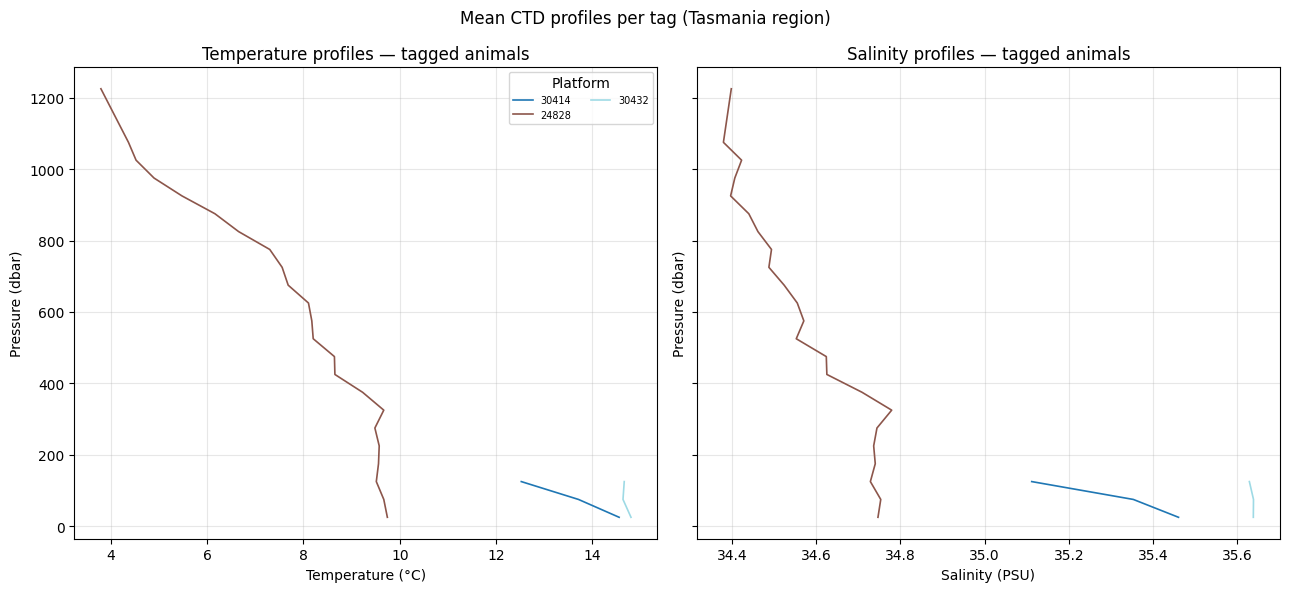

In [6]:

# Mean temperature and salinity profiles per platform
if df_animal.empty:
    print("No data to plot.")
else:
    df_valid = df_animal.dropna(subset=["TEMP", "PSAL", "PRES"])
    platforms = df_valid["PLATFORM_NUMBER"].unique()
    cmap = plt.get_cmap("tab20", len(platforms))

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

    for i, pid in enumerate(platforms):
        sub = df_valid[df_valid["PLATFORM_NUMBER"] == pid]
        # bin by pressure levels
        bins = np.arange(0, sub["PRES"].max() + 50, 50)
        sub = sub.copy()
        sub["pbin"] = pd.cut(sub["PRES"], bins=bins, labels=bins[:-1] + 25)
        grp = sub.groupby("pbin", observed=True)[["TEMP", "PSAL"]].mean()

        axes[0].plot(grp["TEMP"], grp.index.astype(float), "-", linewidth=1.2,
                     color=cmap(i), label=str(pid))
        axes[1].plot(grp["PSAL"], grp.index.astype(float), "-", linewidth=1.2,
                     color=cmap(i), label=str(pid))

    for ax, var, xlab in zip(axes, ["TEMP", "PSAL"], ["Temperature (°C)", "Salinity (PSU)"]):
        ax.invert_yaxis()
        ax.set_xlabel(xlab)
        ax.set_ylabel("Pressure (dbar)")
        ax.grid(True, alpha=0.3)

    axes[0].set_title("Temperature profiles — tagged animals")
    axes[1].set_title("Salinity profiles — tagged animals")
    axes[0].legend(fontsize=7, ncol=2, title="Platform")
    plt.suptitle("Mean CTD profiles per tag (Tasmania region)", fontsize=12)
    plt.tight_layout()
    plt.show()

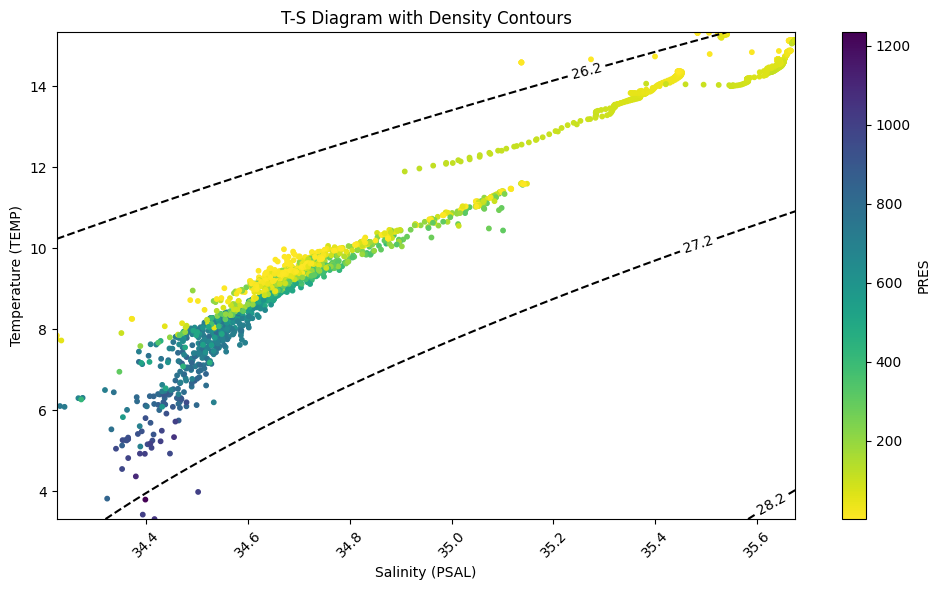

In [7]:

# T-S diagram from animal tag data
if not df_animal.empty:
    df_ts_animal = df_animal.dropna(subset=["TEMP", "PSAL", "PRES"])
    if not df_ts_animal.empty:
        plot_ts_diagram(df_ts_animal, temp_col="TEMP", psal_col="PSAL", z_col="PRES")
    else:
        print("No T/S/P data after filtering.")
else:
    print("No animal tag data in this region.")

---
## 2. Argo Float Profiles near Tasmania

Argo profiling floats provide independent temperature and salinity profiles to 2000 m every ~10 days, providing context for the animal-tag CTD data. We overlay Argo profile locations on the same map and compare T-S water-mass structure.

In [8]:

ds_argo = aodn.get_dataset("argo.parquet")

df_argo = ds_argo.get_data(
    date_start=DATE_START,
    date_end=DATE_END,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)
print(f"Argo rows: {len(df_argo):,}  |  floats: {df_argo['PLATFORM_NUMBER'].nunique()}")
df_argo.head(3)

2026-06-03 15:11:51,728 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/argo.parquet


Argo rows: 3,837,035  |  floats: 124


,PROJECT_NAME,PI_NAME,CYCLE_NUMBER,DIRECTION,DATA_CENTRE,DC_REFERENCE,DATA_STATE_INDICATOR,DATA_MODE,PLATFORM_TYPE,FLOAT_SERIAL_NO,...,HISTORY_DATE,HISTORY_ACTION,HISTORY_PARAMETER,HISTORY_START_PRES,HISTORY_STOP_PRES,HISTORY_PREVIOUS_VALUE,HISTORY_QCTEST,timestamp,PLATFORM_NUMBER,polygon
0,Argo Australia ...,Susan Wijffels ...,105.0,A,CS,5901188/105,2C,D,APEX,2955,...,None,None,None,NaN,NaN,NaN,None,1262304000,5901188,0103000000010000000500000000000000002062400000...
1,Argo Australia ...,Susan Wijffels ...,105.0,A,CS,5901188/105,2C,D,APEX,2955,...,None,None,None,NaN,NaN,NaN,None,1262304000,5901188,0103000000010000000500000000000000002062400000...
2,Argo Australia ...,Susan Wijffels ...,105.0,A,CS,5901188/105,2C,D,APEX,2955,...,None,None,None,NaN,NaN,NaN,None,1262304000,5901188,0103000000010000000500000000000000002062400000...


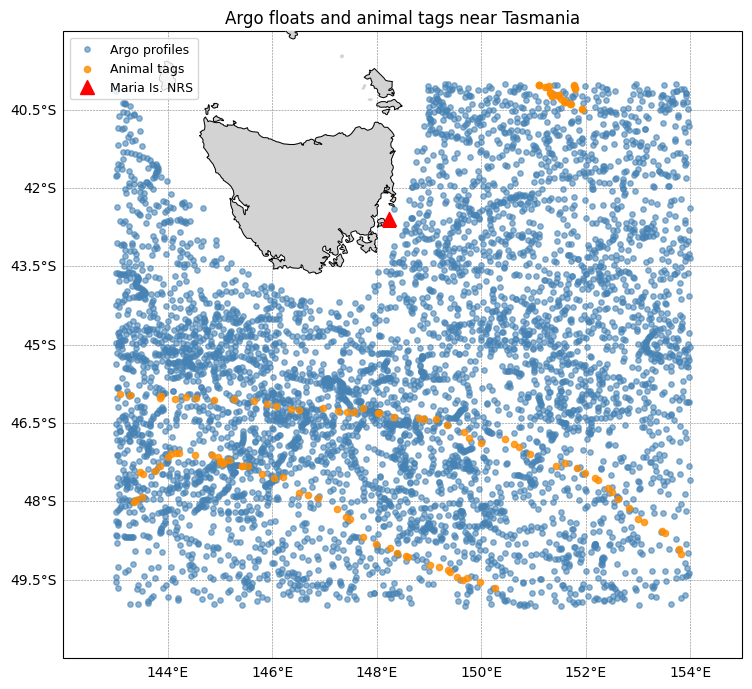

In [9]:

# Map: Argo float positions + animal tracks side by side
if df_argo.empty:
    print("No Argo data in this region/period.")
else:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN - 1, LON_MAX + 1, LAT_MIN - 1, LAT_MAX + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", color="gray")
    gl.top_labels = gl.right_labels = False

    # Argo positions
    argo_unique = df_argo.drop_duplicates(subset=["PLATFORM_NUMBER", "JULD"])
    sc = ax.scatter(argo_unique["LONGITUDE"], argo_unique["LATITUDE"],
                    c="steelblue", s=15, alpha=0.6, transform=ccrs.PlateCarree(),
                    label="Argo profiles", zorder=4)

    # Animal tag positions
    if not df_animal.empty:
        animal_unique = df_animal.drop_duplicates(subset=["PLATFORM_NUMBER", "JULD"]).dropna(subset=["LATITUDE", "LONGITUDE"])
        ax.scatter(animal_unique["LONGITUDE"], animal_unique["LATITUDE"],
                   c="darkorange", s=20, alpha=0.8, transform=ccrs.PlateCarree(),
                   label="Animal tags", zorder=5)

    ax.plot(MARIA_LON, MARIA_LAT, "r^", markersize=10, transform=ccrs.PlateCarree(),
            zorder=6, label="Maria Is. NRS")

    ax.legend(fontsize=9, loc="upper left")
    ax.set_title("Argo floats and animal tags near Tasmania", fontsize=12)
    plt.tight_layout()
    plt.show()

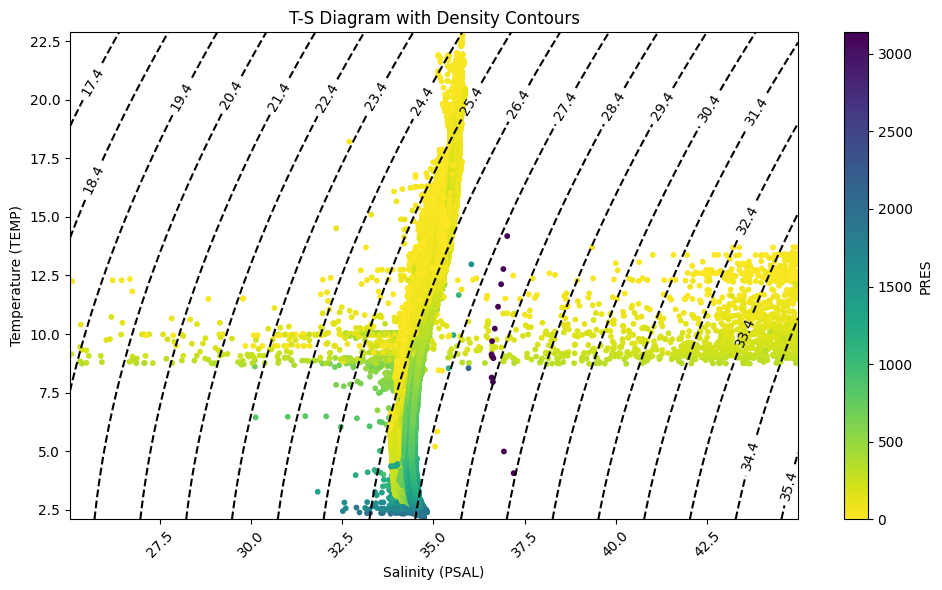

In [10]:

# Argo T-S diagram
if not df_argo.empty:
    df_ts_argo = df_argo.dropna(subset=["TEMP", "PSAL", "PRES"])
    if not df_ts_argo.empty:
        plot_ts_diagram(df_ts_argo, temp_col="TEMP", psal_col="PSAL", z_col="PRES")
    else:
        print("No valid T/S/P data in Argo subset.")
else:
    print("No Argo data to plot.")

---
## 3. Maria Island NRS Mooring — Temperature Time-Series

Maria Island National Reference Station (NRS) is a long-running mooring off the east coast of Tasmania (~42.6 °S, 148.2 °E). It provides a multi-depth temperature record that captures the signature of the East Australian Current (EAC) extension and seasonal thermocline variability. We extract data from the mooring closest to the Maria Island NRS position.

In [11]:

ds_mooring = aodn.get_dataset("mooring_temperature_logger_delayed_qc.parquet")

# Wider Tasmania box to find the Maria Island NRS mooring
df_mooring_all = ds_mooring.get_data(
    date_start=DATE_START,
    date_end=DATE_END,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)
# Show available mooring positions to identify Maria Island NRS
mooring_locs = (
    df_mooring_all.groupby(["LATITUDE", "LONGITUDE"])
    .size()
    .reset_index(name="n_obs")
    .sort_values("n_obs", ascending=False)
)
print(mooring_locs.head(15))

2026-06-03 15:14:02,077 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/mooring_temperature_logger_delayed_qc.parquet


Empty DataFrame
Columns: [LATITUDE, LONGITUDE, n_obs]
Index: []


In [12]:

# Select Maria Island NRS (closest to known position -42.60°S, 148.23°E)
import pandas as pd

if df_mooring_all.empty:
    print("No mooring data found in region.")
else:
    mooring_locs["dist"] = np.sqrt(
        (mooring_locs["LATITUDE"] - MARIA_LAT) ** 2 +
        (mooring_locs["LONGITUDE"] - MARIA_LON) ** 2
    )
    best = mooring_locs.sort_values("dist").iloc[0]
    print(f"Closest mooring site: lat={best['LATITUDE']:.3f}, lon={best['LONGITUDE']:.3f}  (n={best['n_obs']})")

    df_mooring = df_mooring_all[
        (df_mooring_all["LATITUDE"] == best["LATITUDE"]) &
        (df_mooring_all["LONGITUDE"] == best["LONGITUDE"])
    ]
    df_mooring = df_mooring[df_mooring["TEMP_quality_control"].isin([1, 2])].copy()
    print(f"QC-filtered rows: {len(df_mooring):,}  |  nominal depths: {sorted(df_mooring['NOMINAL_DEPTH'].unique())}")

No mooring data found in region.


In [13]:

# Plot temperature time-series per nominal depth (Maria Island NRS)
if not df_mooring_all.empty and "df_mooring" in dir() and not df_mooring.empty:
    depths = sorted(df_mooring["NOMINAL_DEPTH"].dropna().unique())
    cmap_depth = plt.get_cmap("viridis_r", len(depths))

    fig, ax = plt.subplots(figsize=(14, 5))
    for i, d in enumerate(depths):
        sub = df_mooring[df_mooring["NOMINAL_DEPTH"] == d].sort_values("TIME")
        ax.plot(sub["TIME"], sub["TEMP"], lw=0.7, color=cmap_depth(i), label=f"{d:.0f} m")

    sm = plt.cm.ScalarMappable(cmap="viridis_r", norm=plt.Normalize(min(depths), max(depths)))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Nominal depth (m)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title(f"Maria Island NRS — Temperature time-series ({DATE_START} → {DATE_END})")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No mooring data to plot.")

No mooring data to plot.


---
## 4. Gridded Sea Surface Temperature (RAMSSA L4)

The RAMSSA (Regional Australian Multi-Sensor SST Analysis) Level-4 product provides daily, gap-free foundation SST at 1/12° resolution over the Australian region. We plot a representative map showing the SST field around Tasmania and overlay the animal tag fix positions.

In [14]:

ds_sst = aodn.get_dataset("satellite_ghrsst_l4_ramssa_1day_multi_sensor_australia.zarr")
print(ds_sst.get_temporal_extent())

(Timestamp('2006-06-12 12:00:00'), Timestamp('2026-06-01 12:00:00'))


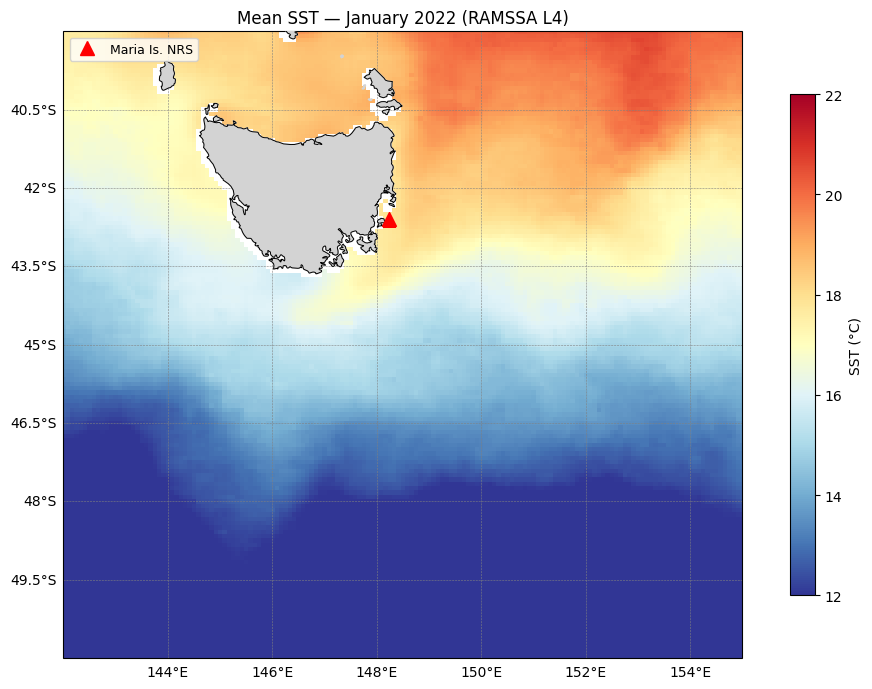

In [15]:

import xarray as xr

xds_sst = ds_sst.zarr_store

# Representative austral summer mean (Jan 2022) — SST in °C
sst_jan = (
    xds_sst["analysed_sst"]
    .sel(time=slice("2022-01-01", "2022-01-31"))
    .sel(lat=slice(LAT_MIN - 1, LAT_MAX + 1), lon=slice(LON_MIN - 1, LON_MAX + 1))
    .mean(dim="time")
    - 273.15  # K → °C
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([LON_MIN - 1, LON_MAX + 1, LAT_MIN - 1, LAT_MAX + 1], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    sst_jan["lon"].values, sst_jan["lat"].values, sst_jan.values,
    cmap="RdYlBu_r", shading="auto", transform=ccrs.PlateCarree(), vmin=12, vmax=22
)
plt.colorbar(mesh, ax=ax, label="SST (°C)", shrink=0.8)

ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=4)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", color="gray")
gl.top_labels = gl.right_labels = False

# Overlay animal tag positions (Jan 2022)
if not df_animal.empty:
    mask_jan = (
        (df_animal["JULD"] >= np.datetime64("2022-01-01")) &
        (df_animal["JULD"] < np.datetime64("2022-02-01"))
    )
    sub_jan = df_animal[mask_jan].dropna(subset=["LATITUDE", "LONGITUDE"])
    if not sub_jan.empty:
        ax.scatter(sub_jan["LONGITUDE"], sub_jan["LATITUDE"],
                   c="k", s=30, zorder=5, transform=ccrs.PlateCarree(), label="Animal fixes (Jan 2022)")

ax.plot(MARIA_LON, MARIA_LAT, "r^", markersize=10, transform=ccrs.PlateCarree(),
        zorder=6, label="Maria Is. NRS")

ax.legend(fontsize=9, loc="upper left")
ax.set_title("Mean SST — January 2022 (RAMSSA L4)", fontsize=12)
plt.tight_layout()
plt.show()

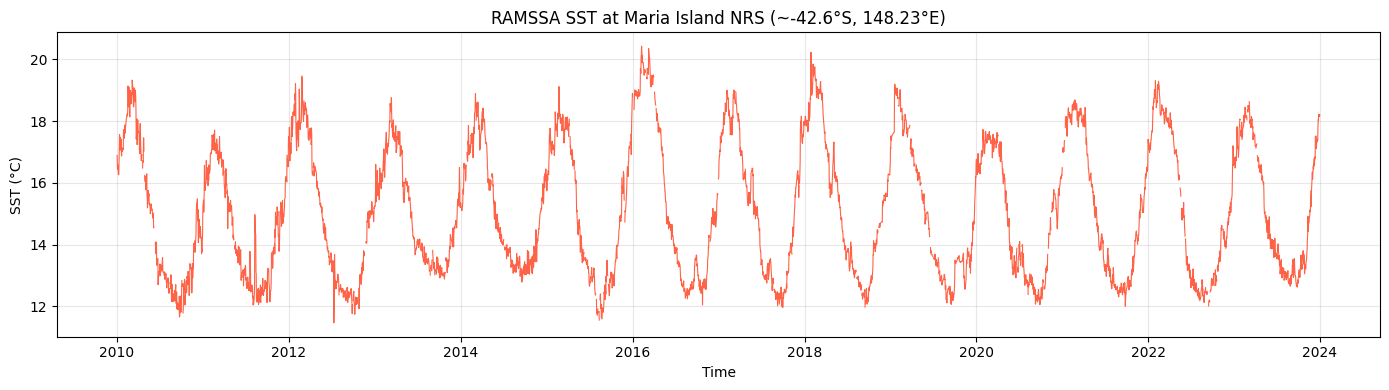

In [16]:

# SST time-series at Maria Island NRS position
sst_ts = (
    xds_sst["analysed_sst"]
    .sel(time=slice(DATE_START, DATE_END))
    .sel(lat=MARIA_LAT, lon=MARIA_LON, method="nearest")
    - 273.15
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sst_ts["time"].values, sst_ts.values, lw=0.8, color="tomato")
ax.set_xlabel("Time")
ax.set_ylabel("SST (°C)")
ax.set_title(f"RAMSSA SST at Maria Island NRS (~{MARIA_LAT}°S, {MARIA_LON}°E)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Gridded Chlorophyll-a (MODIS-Aqua OCI, 1-day)

Surface chlorophyll-a concentration from the MODIS-Aqua satellite (OCI algorithm) indicates phytoplankton biomass and primary productivity — key food web drivers for foraging seals and turtles. We plot mean Chl-a for the same austral summer period and overlay animal fixes.

In [17]:

ds_chl = aodn.get_dataset("satellite_chlorophylla_oci_1day_aqua.zarr")
print(ds_chl.get_temporal_extent())

(Timestamp('2002-07-04 05:30:00'), Timestamp('2024-12-06 05:30:00'))


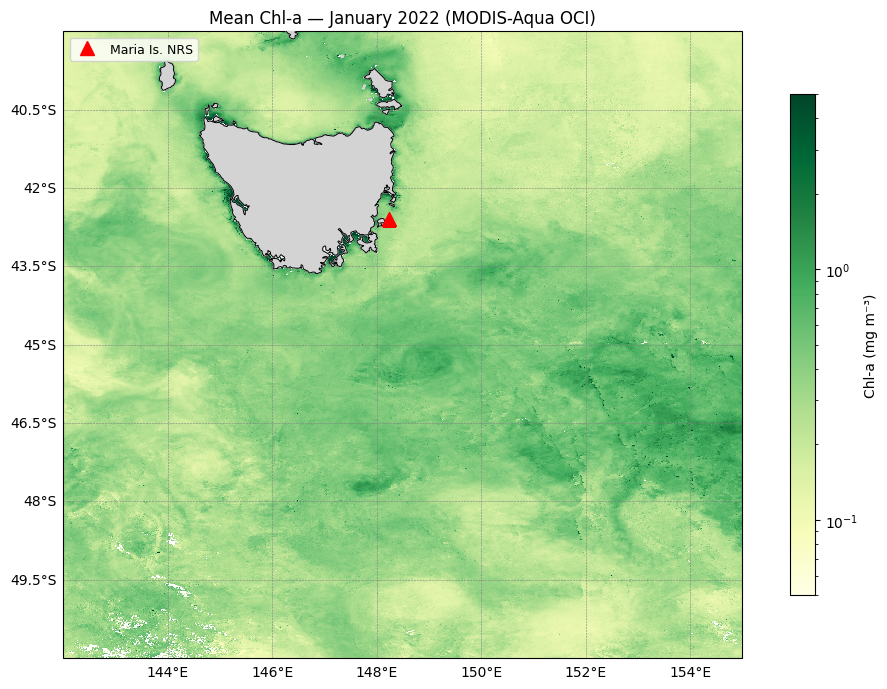

In [18]:

xds_chl = ds_chl.zarr_store

# Latitude is stored in descending order — slice from high to low
chl_jan = (
    xds_chl["chl_oci"]
    .sel(time=slice("2022-01-01", "2022-01-31"))
    .sel(latitude=slice(LAT_MAX + 1, LAT_MIN - 1),
         longitude=slice(LON_MIN - 1, LON_MAX + 1))
    .mean(dim="time")
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([LON_MIN - 1, LON_MAX + 1, LAT_MIN - 1, LAT_MAX + 1], crs=ccrs.PlateCarree())

import matplotlib.colors as mcolors
mesh = ax.pcolormesh(
    chl_jan["longitude"].values, chl_jan["latitude"].values, chl_jan.values,
    cmap="YlGn", shading="auto", transform=ccrs.PlateCarree(),
    norm=mcolors.LogNorm(vmin=0.05, vmax=5.0)
)
plt.colorbar(mesh, ax=ax, label="Chl-a (mg m⁻³)", shrink=0.8)

ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=4)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", color="gray")
gl.top_labels = gl.right_labels = False

# Overlay animal tag positions
if not df_animal.empty:
    mask_jan = (
        (df_animal["JULD"] >= np.datetime64("2022-01-01")) &
        (df_animal["JULD"] < np.datetime64("2022-02-01"))
    )
    sub_jan = df_animal[mask_jan].dropna(subset=["LATITUDE", "LONGITUDE"])
    if not sub_jan.empty:
        ax.scatter(sub_jan["LONGITUDE"], sub_jan["LATITUDE"],
                   c="k", s=30, zorder=5, transform=ccrs.PlateCarree(), label="Animal fixes (Jan 2022)")

ax.plot(MARIA_LON, MARIA_LAT, "r^", markersize=10, transform=ccrs.PlateCarree(),
        zorder=6, label="Maria Is. NRS")

ax.legend(fontsize=9, loc="upper left")
ax.set_title("Mean Chl-a — January 2022 (MODIS-Aqua OCI)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Combined Contextual Summary — SST vs Chl-a time-series at Maria Island NRS

We compare the SST (RAMSSA L4) and Chl-a (MODIS OCI) time-series at the Maria Island NRS location to identify productive upwelling periods that may drive seal foraging behaviour.

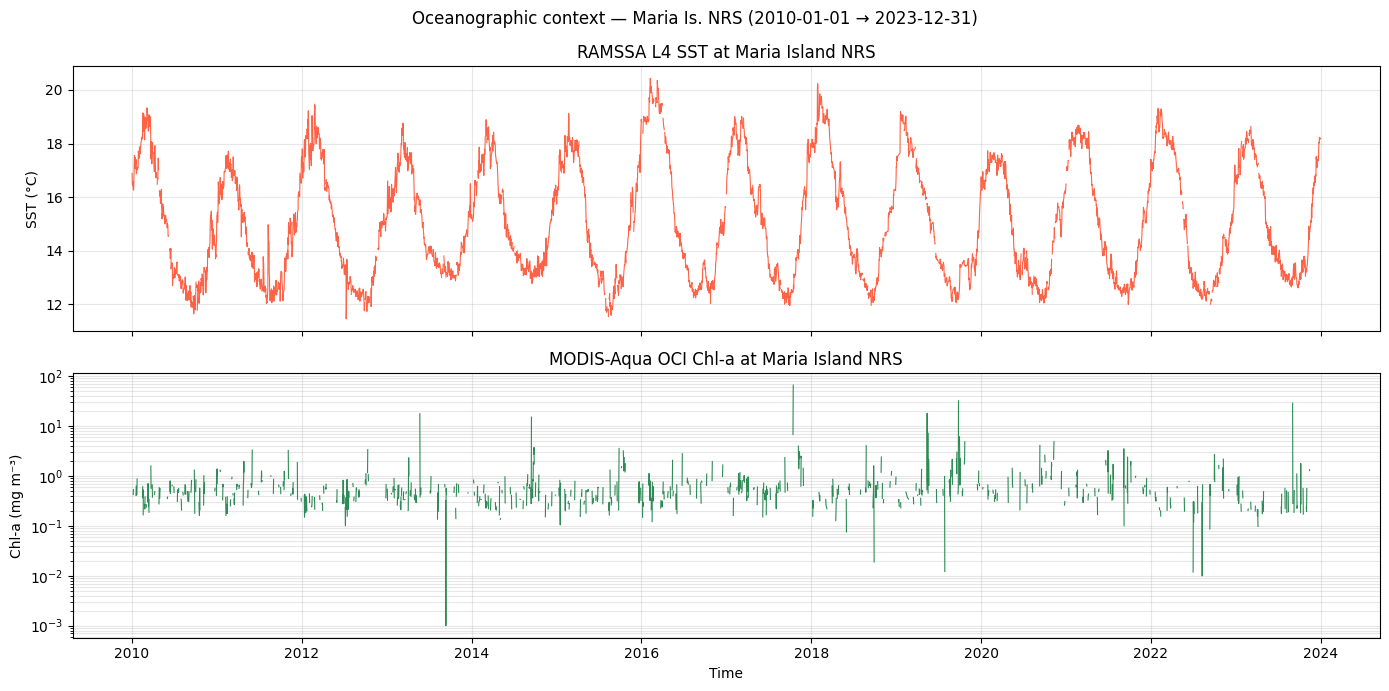

In [19]:

# Chl-a time-series at Maria Island NRS
chl_ts = (
    xds_chl["chl_oci"]
    .sel(time=slice(DATE_START, DATE_END))
    .sel(latitude=MARIA_LAT, longitude=MARIA_LON, method="nearest")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(sst_ts["time"].values, sst_ts.values, lw=0.8, color="tomato")
axes[0].set_ylabel("SST (°C)")
axes[0].set_title("RAMSSA L4 SST at Maria Island NRS")
axes[0].grid(True, alpha=0.3)

axes[1].plot(chl_ts["time"].values, chl_ts.values, lw=0.8, color="seagreen")
axes[1].set_yscale("log")
axes[1].set_ylabel("Chl-a (mg m⁻³)")
axes[1].set_xlabel("Time")
axes[1].set_title("MODIS-Aqua OCI Chl-a at Maria Island NRS")
axes[1].grid(True, alpha=0.3, which="both")

plt.suptitle(f"Oceanographic context — Maria Is. NRS ({DATE_START} → {DATE_END})", fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary

| Dataset | Source | Purpose |
|---------|--------|---------|
| `animal_ctd_satellite_relay_tagging_delayed_qc` | IMOS Animal Tracking / MEOP | Foraging tracks + CTD profiles (seals, turtles) |
| `argo` | Argo Australia | Independent T/S profiles to 2000 m |
| `mooring_temperature_logger_delayed_qc` | ANMN Maria Island NRS | Multi-depth temperature time-series |
| `satellite_ghrsst_l4_ramssa_1day_multi_sensor_australia` | BOM RAMSSA | Daily gap-free SST at 1/12° |
| `satellite_chlorophylla_oci_1day_aqua` | IMOS / NASA MODIS-Aqua | Daily surface Chl-a (phytoplankton biomass) |

**Key findings to explore:**
- Seasonal thermocline structure seen in mooring and animal-tag CTD profiles.
- EAC extension warm-core eddies visible in SST maps — potential foraging hotspots.
- High Chl-a patches along the Tasmanian shelf break align with known seal foraging areas.
- Argo and animal-tag T-S diagrams reveal Sub-Antarctic Mode Water (SAMW) signatures at depth.